In [ ]:
!pip install kagglehub tqdm opencv-python -q

In [ ]:
import kagglehub
import os
import cv2
from tqdm import tqdm

# Download latest version of MSVD
path = kagglehub.dataset_download("steveandreasimmanuel/msvd-video-caption")
print("Path to dataset files:", path)

# Based on common MSVD structures, your videos are usually in a subfolder
# We will search for the folder containing the video files (mp4/avi)
video_root = None
for root, dirs, files in os.walk(path):
    if any(f.endswith(('.mp4', '.avi')) for f in files):
        video_root = root
        break

print(f"Videos found in: {video_root}")

100%|██████████| 11.4G/11.4G [06:53<00:00, 29.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/steveandreasimmanuel/msvd-video-caption/versions/2
Videos found in: None


In [ ]:
import os

path = "/root/.cache/kagglehub/datasets/steveandreasimmanuel/msvd-video-caption/versions/2"

# List the first 2 levels of directories to find the video folder
print("--- Directory Structure ---")
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    if level < 2:
        print(f"{'  ' * level}[{os.path.basename(root)}/]")
        # Check for any video files in this folder
        video_files = [f for f in files if f.lower().endswith(('.mp4', '.avi', '.mkv', '.webm'))]
        if video_files:
            print(f"{'  ' * (level + 1)} Found {len(video_files)} videos (Example: {video_files[0]})")

--- Directory Structure ---
[2/]
  [validation/]
  [train/]
  [testing/]


In [ ]:
import os
import shutil
from tqdm import tqdm

# Define paths based on your kagglehub output
dataset_root = "/root/.cache/kagglehub/datasets/steveandreasimmanuel/msvd-video-caption/versions/2"
output_root = "/content/msvd_progress_frames"

# The splits in your directory structure
splits = ['train', 'validation', 'testing']

def sample_progress_frames(source_root, target_root, num_frames=8):
    if not os.path.exists(target_root):
        os.makedirs(target_root)

    for split in splits:
        split_path = os.path.join(source_root, split)
        if not os.path.exists(split_path): continue

        # Each folder here is a video ID (e.g., 'vid1', 'vid2')
        video_folders = [d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))]

        for video_id in tqdm(video_folders, desc=f"Sampling {split}"):
            video_folder_path = os.path.join(split_path, video_id)
            all_frames = sorted([f for f in os.listdir(video_folder_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])

            total_available = len(all_frames)
            if total_available < num_frames:
                continue # Skip videos with too few frames

            # Progress-aware logic: Pick 8 frames from Start to End
            indices = [int(i * (total_available - 1) / (num_frames - 1)) for i in range(num_frames)]

            # Create a dedicated folder for this video's sequence
            save_path = os.path.join(target_root, video_id)
            os.makedirs(save_path, exist_ok=True)

            for i, idx in enumerate(indices):
                src_file = os.path.join(video_folder_path, all_frames[idx])
                # Rename to maintain temporal order: 0.jpg, 1.jpg, ... 7.jpg
                dst_file = os.path.join(save_path, f"{i}.jpg")
                shutil.copy(src_file, dst_file)

sample_progress_frames(dataset_root, output_root)
print(f"\nSampling complete. Your progress-aware frames are in: {output_root}")

Sampling testing: 100%|██████████| 670/670 [00:11<00:00, 57.98it/s]


Sampling complete. Your progress-aware frames are in: /content/msvd_progress_frames


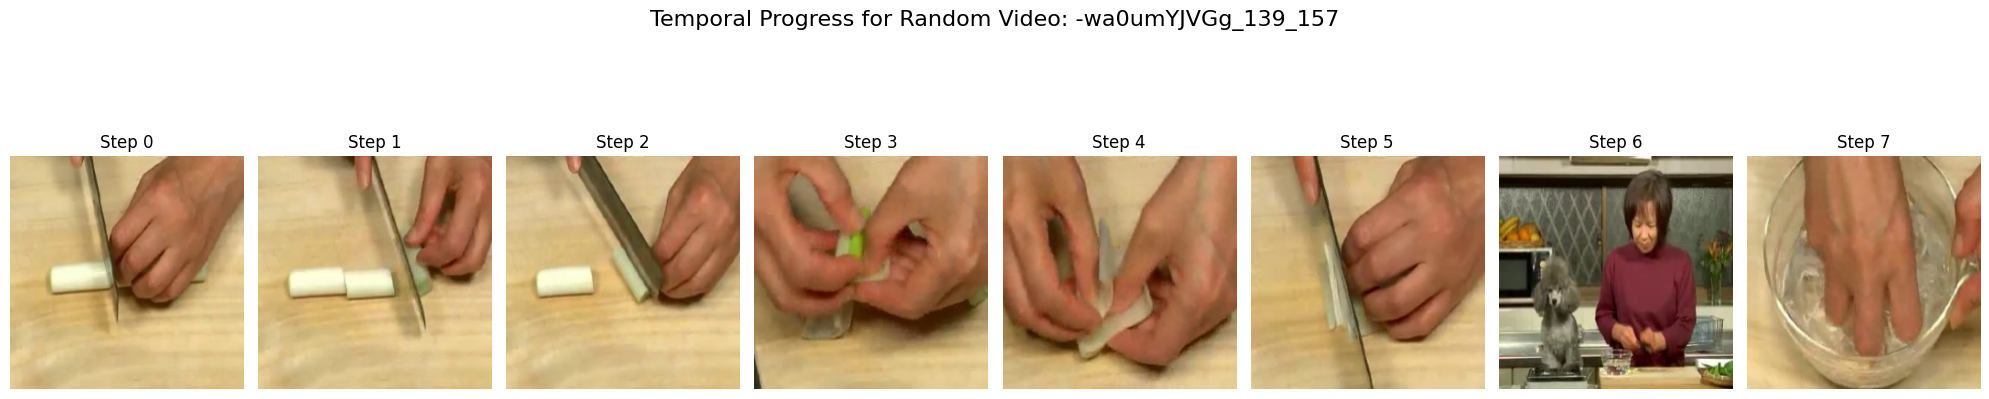

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os
import random

def visualize_random_progress_video(output_root):
    # 1. Get a list of all video folders in the output directory
    video_ids = [d for d in os.listdir(output_root) if os.path.isdir(os.path.join(output_root, d))]

    if not video_ids:
        print("No folders found in the specified output_root.")
        return

    # 2. Select one video ID at random
    random_id = random.choice(video_ids)
    path = os.path.join(output_root, random_id)

    # 3. Get and sort the frames numerically to ensure temporal order (0.jpg, 1.jpg, etc.)
    frames = sorted([f for f in os.listdir(path) if f.endswith('.jpg')],
                    key=lambda x: int(x.split('.')[0]))

    # 4. Create the visualization grid
    num_frames = len(frames)
    fig, axes = plt.subplots(1, num_frames, figsize=(20, 5))
    fig.suptitle(f"Temporal Progress for Random Video: {random_id}", fontsize=16)

    for i, frame_name in enumerate(frames):
        img_path = os.path.join(path, frame_name)
        img = cv2.imread(img_path)

        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i].imshow(img)
            axes[i].set_title(f"Step {i}")
        else:
            axes[i].set_title(f"Error Loading Step {i}")

        axes[i].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Run the visualization
# Ensure 'output_root' matches the directory where your sampled frames are stored
visualize_random_progress_video(output_root)